In [1]:
import jets
import jets.metrics as metrics

In [176]:
config = {
    'exp_name': 'log-test-1',
    'visual': {
        'fields': ['q', 'v'],
        'spectra': ['z', 'e'],
        'means' : ['z_mean', 'e_mean'],
        # 'means' : ['z_dot', 'e_dot'],
    },
    'atmosphere': {
        'n_grid': 256, 
        'params': {
            'initial': 'zero', 
            'forcing': 'norm',
            'p': 2,
            'nu': 4e-8, 
            'r': 0.5,
            'epsilon': 8*5.0,
            'kf': 16,
            'dkf': 2,
            'forcing_dt': 0.1/100,
        }
    },
    'integrator': {
        'method': 'rk4',
        'interval': 0.1,
        'n_points': 100,
    },
}

model = jets.Driver()
model.setup(**config)
model.start()
print(model.descript())

def check_z_saturation(climate, show=False):
    if len(climate['t'])<=2:
        return False, None
    t, z_mean = climate['t'][1::], climate['z_mean'][1::]
    z_params, z_found = metrics.find_saturation(t, z_mean)
    if z_found:
        if show:
            metrics.plot_saturation(t, z_mean, z_params, 'z_mean')
        return True, z_params
    else:
        return False, None
    
def check_e_saturation(climate, show=False):
    if len(climate['t'])<=2:
        return False, None
    t, e_mean = climate['t'][1::], climate['e_mean'][1::]
    e_params, e_found = metrics.find_saturation(t, e_mean)
    if e_found:
        if show:
            metrics.plot_saturation(t, e_mean, e_params, 'e_mean')
        return True, e_params
    else:
        return False, None
    
def check_saturation(climate, show=False):
    stop_z, data_z = check_z_saturation(climate, show)
    stop_e, data_e = check_e_saturation(climate, show)
    stop = stop_e and stop_z
    data = {
        'e_mean': data_e,
        'z_mean': data_z
    }
    return stop, data

[meta]
model = qgc-1
type = quasi-geostrophic
coord = cartesian
approach = spectral-1

[atmosphere]
initial = zero
forcing = norm
initial_seed = 42
forcing_seed = 42
p = 2
beta = 0.0
nu = 4e-08
r = 0.1
kappa = 0.0
epsilon = 10.0
kf = 16
dkf = 2
sigma = 1.0
forcing_dt = 0.001

[integrator]
method = rk4
interval = 0.1
n_points = 100




In [177]:
climate = model.climate

In [178]:
e_dot = climate['e_dot'].mean()
z_dot = climate['z_dot'].mean()

z_dot, e_dot
# print(1/climate['e_mean'].values[-1]**0.5)

(<xarray.DataArray 'z_dot' ()> Size: 8B
 Array(0., dtype=float64),
 <xarray.DataArray 'e_dot' ()> Size: 8B
 Array(0., dtype=float64))

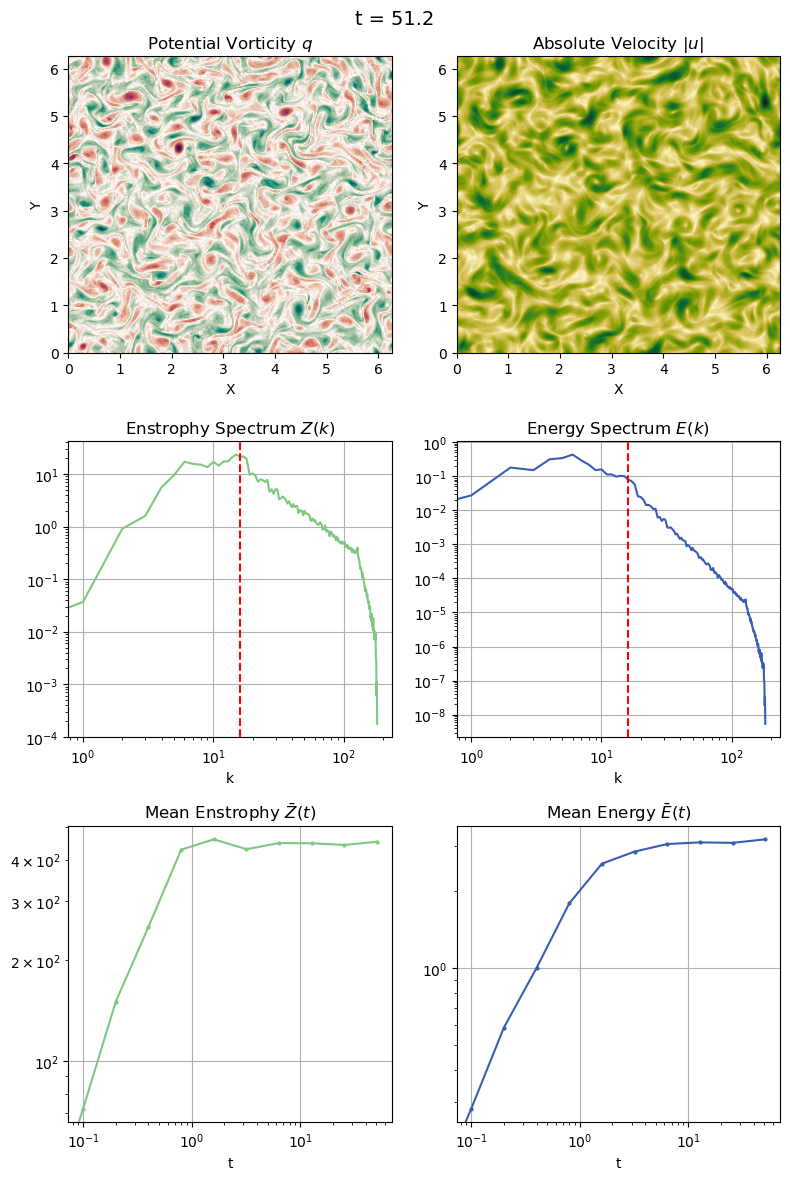

100%|██████████| 11/11 [03:11<00:00, 17.37s/it]


In [179]:
data = model.run(11, show=True,logtime=True, tau=2)

In [180]:
climate = model.climate

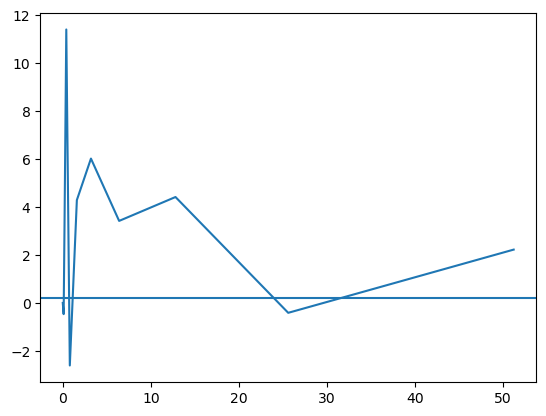

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

def moving_average_with_time(data, time, n):
    """
    Скользящее среднее по окну размера n (последние n точек, включая текущую).
    Возвращает:
      - z_mean: массив той же длины, что и data, первые n-1 элементов = NaN
      - t_mean: массив той же длины (копия t), чтобы сохранить соответствие индексов
    """
    window = np.ones(n) / n
    conv = np.convolve(data, window, mode='valid')  # длина len(data)-n+1
    z_mean = np.concatenate(([np.nan]*(n-1), conv))
    # t_mean — просто копия t (можно и без копии, но для ясности)
    t_mean = time.copy()
    return z_mean, t_mean

kf = config['atmosphere']['params']['kf']
dkf = config['atmosphere']['params']['dkf']
z_dot, t = climate['z_dot'], climate['t']
e_dot, t = climate['e_dot'], climate['t']
z_dot_mean = np.cumsum(z_dot) / np.arange(1, len(z_dot) + 1)
e_dot_mean = np.cumsum(e_dot) / np.arange(1, len(e_dot) + 1)
# z_dot_mean, t = moving_average_with_time(z_dot, t, win)
# e_dot_mean, t = moving_average_with_time(e_dot, t, win)

# e_dot_mean_est = z_dot_mean/kf**2
# e_dot_mean_true = z_dot_mean/kf**2 * (1 + delta)
# diff_est = (e_dot_mean_est - e_dot_mean)
# diff_true = (e_dot_mean_true - e_dot_mean)
# plt.plot(t[100::], diff_est[100::], label='est')
# plt.plot(t[100::], diff_true[100::], label='true')
# plt.legend()
# plt.axvline(t[200])
# plt.axhline(z_dot_mean_norm[200])
plt.plot(t, e_dot)
plt.axhline(0.1912)


/home/vchernosov/miniconda3/envs/climate/lib/python3.11/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


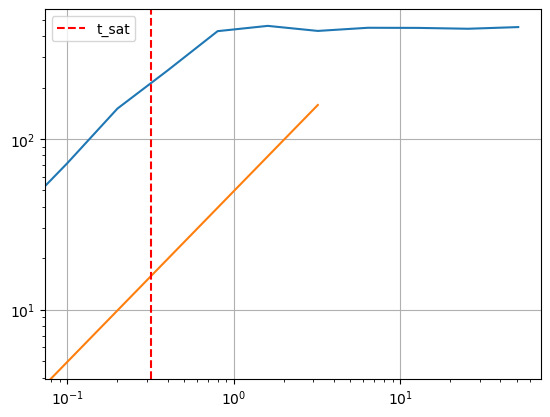

In [182]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

eta = z_dot_mean[-1] #climate['z_dot'].mean()
eps = e_dot_mean[-1]#climate['e_dot'].mean()
r = config['atmosphere']['params']['r']
nu = config['atmosphere']['params']['nu']
p = config['atmosphere']['params']['p']
kf = config['atmosphere']['params']['kf']
tau_nl = (eta)**(-1/3)
k_diss = 1/(tau_nl * nu)**(1/(2*p))
N_oct = np.log(k_diss/kf) / np.log(2)
t_sat_Z = tau_nl * N_oct
t_sat_E = 1/(2*r)

e_mean, z_mean, t = climate['e_mean'], climate['z_mean'], climate['t']
a, b = 1, 3.9
log_y = a * np.log(t[t<4]) + b 
plt.loglog(t, z_mean)
plt.loglog(t[t<4], np.exp(log_y))
plt.axvline(t_sat_Z, color='r', linestyle='--', label='t_sat')
plt.legend()
plt.grid(True)
plt.show()
clear_output(wait=True)

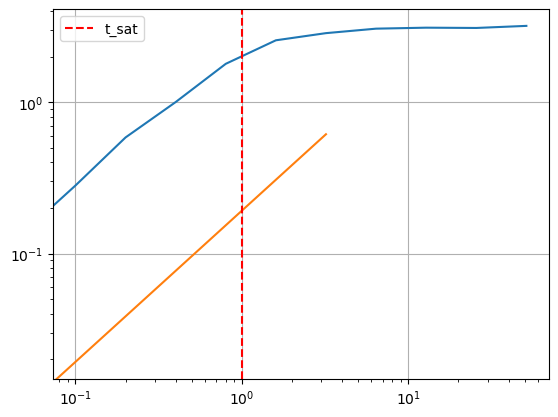

In [183]:
a, b = 1, -1.65
log_y = a * np.log(t[t<4]) + b 
plt.loglog(t, e_mean)
plt.loglog(t[t<4], np.exp(log_y))
plt.axvline(t_sat_E, color='r', linestyle='--', label='t_sat')
plt.legend()
plt.grid(True)
plt.show()
clear_output(wait=True)

Оптимальные параметры:
E0 = 3.0750 | 1.0722
t_0 = 1/gamma = 0.9435 | 0.9435
Стандартные отклонения: E0 ± 0.0278, gamma ± 0.0362


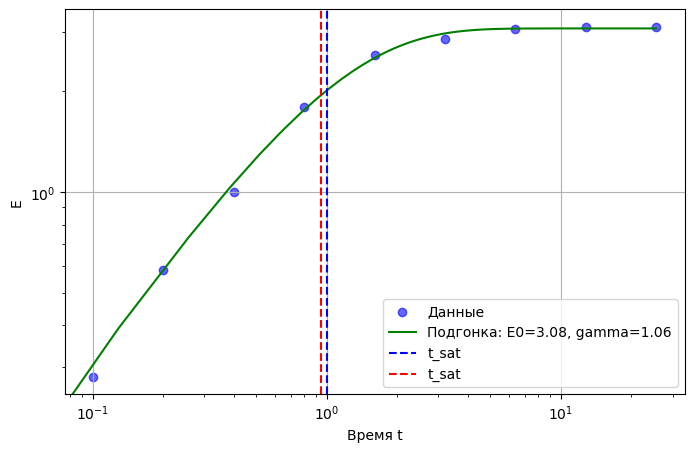

In [198]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Определяем модель
def model_fit(t, E0, gamma):
    return E0 * (1 - np.exp(-gamma * t))

E_sat = eps * 1/(2*r)
t_sat_E = 1/(2*r)

# 2. Ваши данные (замените на свои массивы)
# Например, сгенерируем «шумные» данные для демонстрации
# t = np.linspace(0, 10, 50)                # время
# E_true = 5.0 * (1 - np.exp(-0.8 * t))     # истинная кривая
# E_data = E_true + 0.2 * np.random.normal(size=len(t))  # добавляем шум
for k in range(8, len(climate['t'].values)):
    clear_output(wait=True)
    part = k
    E_data, t = climate['e_mean'].values[:part:], climate['t'].values[:part:]
    p0 = [E_sat, 1/t_sat_E] 
    # Ограничения: E0 > 0, gamma > 0 (опционально)
    bounds = ([0, 0], [np.inf, np.inf])

    # Выполняем подгонку
    popt, pcov = curve_fit(model_fit, t, E_data, p0=p0, bounds=bounds)

    E0_opt, gamma_opt = popt
    t0_opt = 1/gamma_opt
    print(f"Оптимальные параметры:")
    print(f"E0 = {E0_opt:.4f} | {E0_opt/E_sat:.4f}")
    print(f"t_0 = 1/gamma = {1/gamma_opt:.4f} | {t0_opt/t_sat_E:.4f}")
    # print(f"eps_est = {eps_opt:.4f}")
    # Оценка погрешностей (стандартные отклонения)
    perr = np.sqrt(np.diag(pcov))
    print(f"Стандартные отклонения: E0 ± {perr[0]:.4f}, gamma ± {perr[1]:.4f}")

    # 4. Визуализация
    t_fit = np.linspace(t.min(), t.max(), 200)
    E_fit = model_fit(t_fit, *popt)

    plt.figure(figsize=(8, 5))
    plt.scatter(t, E_data, label='Данные', color='blue', alpha=0.6)
    plt.loglog(t_fit, E_fit, 'g-', label=f'Подгонка: E0={E0_opt:.2f}, gamma={gamma_opt:.2f}')
    plt.axvline(t_sat_E, color='b', linestyle='--', label='t_sat')
    plt.axvline(t0_opt, color='r', linestyle='--', label='t_sat')
    plt.xlabel('Время t')
    plt.ylabel('E')
    plt.legend()
    plt.grid(True)
    plt.show()

In [199]:
Af = config['atmosphere']['params']['epsilon']
kf = config['atmosphere']['params']['kf']
eps_opt = E0_opt/t0_opt
eps_est = e_dot_mean[-1].values
eps_th = Af**2/kf**2
eps_eff = 1/2
eps_est, eps_opt, eps_th * eps_eff

(array(2.86795687), np.float64(3.259054901478869), 3.125)

In [201]:
E0_est = eps_opt/(2*r)
t0_est = 1/(2*r)

t0_opt, t0_est

(np.float64(0.943530434244795), 1.0)

In [167]:
# 1. Определяем модель
def model_fit(t, E0, gamma):
    return E0 * (1 - np.exp(-gamma * t))

eps = e_dot_mean
E_sat = eps * 1/(2*r)
t_sat_E = 1/(2*r)

E_sat_est = []
t_sat_E_est = []
t_sim = []

for k in range(50, len(climate['t'].values)):
    clear_output(wait=True)
    part = k
    E_data, t = climate['e_mean'].values[:part:], climate['t'].values[:part:]
    p0 = [E_sat[k], 1/t_sat_E] 
    # Ограничения: E0 > 0, gamma > 0 (опционально)
    bounds = ([0, 0], [np.inf, np.inf])

    # Выполняем подгонку3,
    popt, pcov = curve_fit(model_fit, t, E_data, p0=p0, bounds=bounds)

    E0_opt, gamma_opt = popt
    t0_opt = 1/gamma_opt

    E_sat_est.append(E0_opt)
    t_sat_E_est.append(t0_opt)
    t_sim.append(t.max())
    print(f"Оптимальные параметры:")
    print(f"E0 = {E0_opt:.4f} | {E_sat[k]:.4f}")
    print(f"t_0 = 1/gamma = {1/gamma_opt:.4f} | {t_sat_E:.4f}")

    # Оценка погрешностей (стандартные отклонения)
    perr = np.sqrt(np.diag(pcov))
    print(f"Стандартные отклонения: E0 ± {perr[0]:.4f}, gamma ± {perr[1]:.4f}")

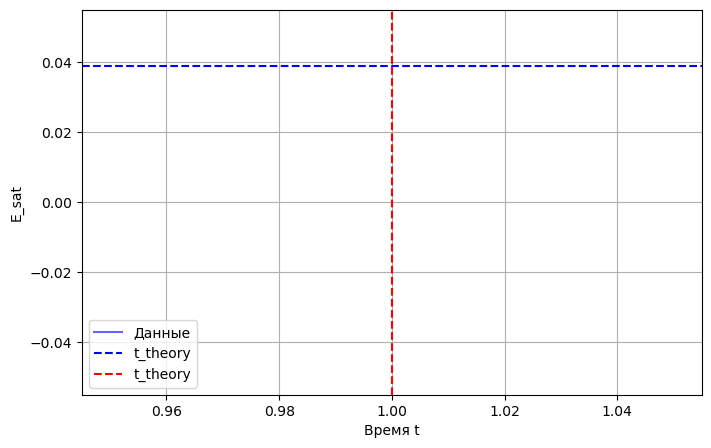

In [168]:
plt.figure(figsize=(8, 5))
plt.plot(t_sim, E_sat_est, label='Данные', color='blue', alpha=0.6)
plt.axhline(E_sat[-1], color='b', linestyle='--', label='t_theory')
plt.axvline(t_sat_E, color='r', linestyle='--', label='t_theory')
plt.xlabel('Время t')
plt.ylabel('E_sat')
plt.legend()
plt.grid(True)
plt.show()
clear_output(wait=True)

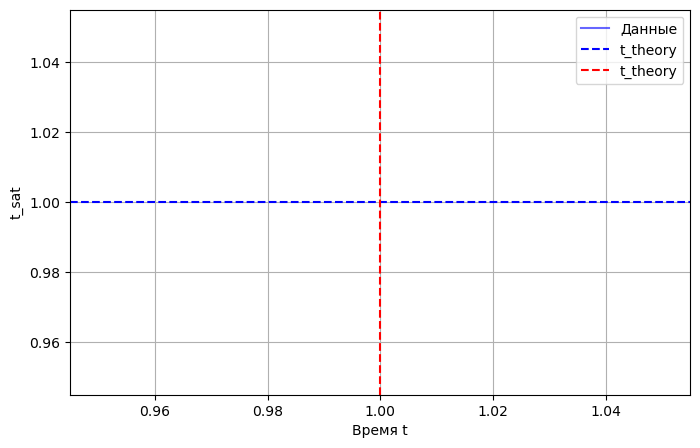

In [169]:
plt.figure(figsize=(8, 5))
plt.plot(t_sim, t_sat_E_est, label='Данные', color='blue', alpha=0.6)
plt.axhline(t_sat_E, color='b', linestyle='--', label='t_theory')
plt.axvline(t_sat_E, color='r', linestyle='--', label='t_theory')
plt.xlabel('Время t')
plt.ylabel('t_sat')
plt.legend()
plt.grid(True)
plt.show()
clear_output(wait=True)

Оптимальные параметры:
Z0 = 451.1301 | 2.5864
t_0 = 1/gamma = 0.4340 | 1.9643
Стандартные отклонения: Z0 ± 10.7229, gamma ± 0.2318


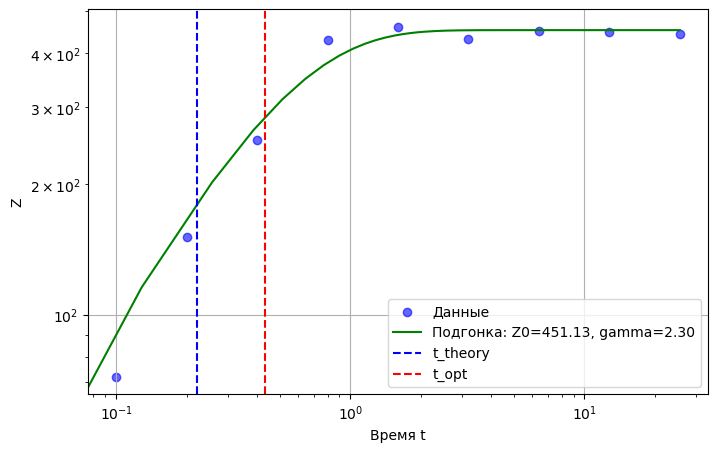

In [186]:
# 1. Определяем модель
def model_fit(t, E0, gamma):
    return E0 * (1 - np.exp(-gamma * t))


# eta = np.full((len(z_dot_mean)), z_dot_mean.values[-1])
eta = z_dot_mean[-1]
Z_sat = eta**(2/3) * np.log(k_diss/kf)
t_sat_Z = eta**(-1/3) * np.log(k_diss/kf) 

# 2. Ваши данные (замените на свои массивы)
# Например, сгенерируем «шумные» данные для демонстрации
# t = np.linspace(0, 10, 50)                # время
# E_true = 5.0 * (1 - np.exp(-0.8 * t))     # истинная кривая
# E_data = E_true + 0.2 * np.random.normal(size=len(t))  # добавляем шум
for k in range(8, len(climate['t'].values)):
    p0 = [Z_sat, 1/t_sat_Z] 
    part = k
    Z_data, t = climate['z_mean'].values[:part:], climate['t'].values[:part:]

    # Ограничения: E0 > 0, gamma > 0 (опционально)
    bounds = ([0, 0], [np.inf, np.inf])

    # Выполняем подгонку
    popt, pcov = curve_fit(model_fit, t, Z_data, p0=p0, bounds=bounds)

    Z0_opt, gamma_opt = popt
    t0_opt = 1/gamma_opt
    print(f"Оптимальные параметры:")
    print(f"Z0 = {Z0_opt:.4f} | {Z0_opt/Z_sat:.4f}")
    print(f"t_0 = 1/gamma = {t0_opt:.4f} | {t0_opt/t_sat_Z:.4f}")

    # Оценка погрешностей (стандартные отклонения)
    perr = np.sqrt(np.diag(pcov))
    print(f"Стандартные отклонения: Z0 ± {perr[0]:.4f}, gamma ± {perr[1]:.4f}")

    # 4. Визуализация
    t_fit = np.linspace(t.min(), t.max(), 200)
    Z_fit = model_fit(t_fit, *popt)

    plt.figure(figsize=(8, 5))
    plt.scatter(t, Z_data, label='Данные', color='blue', alpha=0.6)
    plt.loglog(t_fit, Z_fit, 'g-', label=f'Подгонка: Z0={Z0_opt:.2f}, gamma={gamma_opt:.2f}')
    plt.axvline(t_sat_Z, color='b', linestyle='--', label='t_theory')
    plt.axvline(t0_opt, color='r', linestyle='--', label='t_opt')
    plt.xlabel('Время t')
    plt.ylabel('Z')
    plt.legend()
    plt.grid(True)
    plt.show()
    clear_output(wait=True)

In [188]:
Af = config['atmosphere']['params']['epsilon']
kf = config['atmosphere']['params']['kf']
N_f = np.log(k_diss/kf).values
eta_est = z_dot_mean[-1].values
eta_opt = Z0_opt/t0_opt
eta_th = Af**2
eta_eff = 7/10
eta_est, eta_opt, eta_th*eta_eff


(array(789.45628152), np.float64(1039.493371994255), 1120.0)

In [197]:
tau_nl = (eta_opt)**(-1/3)
k_diss = 1/(tau_nl * nu)**(1/(2*p))
t0_est = 2 * (eta_opt)**(-1/3) * np.log(k_diss/(kf))
Z0_est = eta_opt * t0_est
t0_est, t0_opt
Z0_est, Z0_opt

(np.float64(423.77926494689444), np.float64(451.13005653410903))

In [273]:
# 1. Определяем модель
def model(t, E0, gamma):
    return E0 * (1 - np.exp(-gamma * t))

eta = z_dot_mean
Z_sat = 3.4 * eta**(2/3) * np.log(k_diss/kf)
t_sat_Z = 1.8 * eta**(-1/3) * np.log(k_diss/kf) 

Z_sat_est = []
t_sat_est = []
t_sim = []
# 2. Ваши данные (замените на свои массивы)
# Например, сгенерируем «шумные» данные для демонстрации
# t = np.linspace(0, 10, 50)                # время
# E_true = 5.0 * (1 - np.exp(-0.8 * t))     # истинная кривая
# E_data = E_true + 0.2 * np.random.normal(size=len(t))  # добавляем шум
for k in range(20, len(climate['t'].values)):
    clear_output(wait=True)
    p0 = [Z_sat[k], 1/t_sat_Z[k]] 
    part = k
    Z_data, t = climate['z_mean'].values[:part:], climate['t'].values[:part:]

    # Ограничения: E0 > 0, gamma > 0 (опционально)
    bounds = ([0, 0], [np.inf, np.inf])

    # Выполняем подгонку
    popt, pcov = curve_fit(model, t, Z_data, p0=p0, bounds=bounds)

    Z0_opt, gamma_opt = popt
    t0_opt = 1/gamma_opt
    Z_sat_est.append(Z0_opt)
    t_sat_est.append(t0_opt)
    t_sim.append(t.max())
    print(f"Оптимальные параметры:")
    print(f"Z0 = {Z0_opt:.4f} | {Z0_opt/Z_sat[k]:.4f}")
    print(f"t_0 = 1/gamma = {t0_opt:.4f} | {t0_opt/t_sat_Z[k]:.4f}")
    
    # Оценка погрешностей (стандартные отклонения)
    perr = np.sqrt(np.diag(pcov))
    print(f"Стандартные отклонения: Z0 ± {perr[0]:.4f}, gamma ± {perr[1]:.4f}")


Оптимальные параметры:
Z0 = 80.8131 | 1.0042
t_0 = 1/gamma = 0.9005 | 0.9828
Стандартные отклонения: Z0 ± 0.2403, gamma ± 0.0372


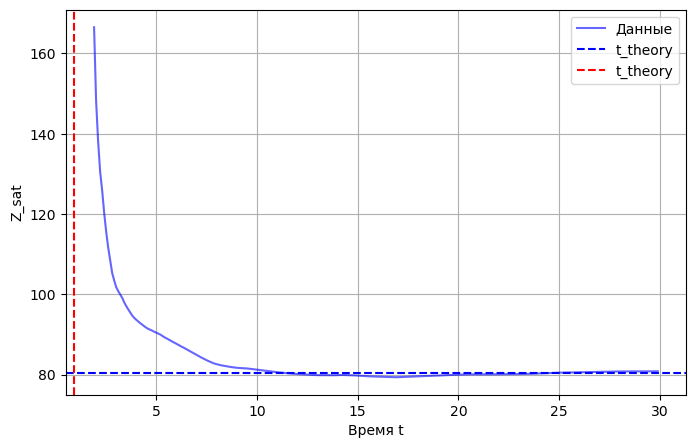

In [274]:
plt.figure(figsize=(8, 5))
plt.plot(t_sim, Z_sat_est, label='Данные', color='blue', alpha=0.6)
plt.axhline(Z_sat[-1], color='b', linestyle='--', label='t_theory')
plt.axvline(t_sat_Z[-1], color='r', linestyle='--', label='t_theory')
plt.xlabel('Время t')
plt.ylabel('Z_sat')
plt.legend()
plt.grid(True)
plt.show()
clear_output(wait=True)

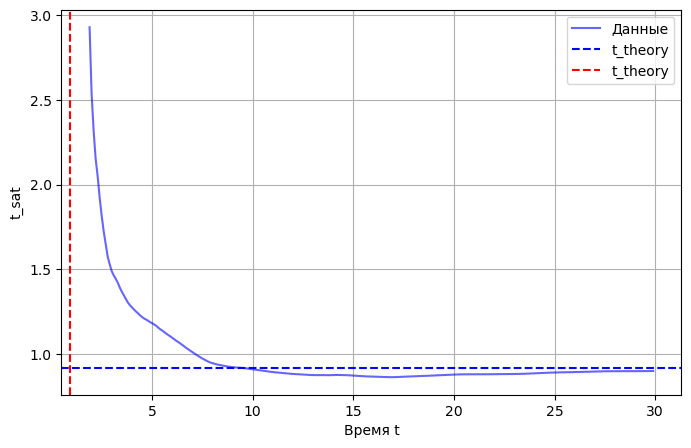

In [275]:
plt.figure(figsize=(8, 5))
plt.plot(t_sim, t_sat_est, label='Данные', color='blue', alpha=0.6)
plt.axhline(t_sat_Z[-1], color='b', linestyle='--', label='t_theory')
plt.axvline(t_sat_Z[-1], color='r', linestyle='--', label='t_theory')
plt.xlabel('Время t')
plt.ylabel('t_sat')
plt.legend()
plt.grid(True)
plt.show()
clear_output(wait=True)

In [41]:
79.9546/28.7969 - np.exp(1)


np.float64(0.05821841983156961)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output


t_sat = data['z_mean']['t_sat']
eta = climate['z_dot'].mean()
nu = config['atmosphere']['params']['nu']
p = config['atmosphere']['params']['p']
kf = config['atmosphere']['params']['kf']
k_diss = 1/(t_sat * nu)**(1/(2*p))
tau_nl = (eta)**(-1/3)
N_oct = np.log(k_diss/kf) / np.log(2)
t_sat_theory = tau_nl * N_oct
С_cas = t_sat/(tau_nl * N_oct)
print(t_sat, t_sat_theory, N_oct, С_cas)

e_mean, z_mean, t = climate['e_mean'], climate['z_mean'], climate['t']
# e, z = E.isel(t=-1), Z.isel(t=-1)
a, b = 1, 3.88
log_y = a * np.log(t[t<4]) + b 
plt.loglog(t, z_mean)
plt.loglog(t[t<4], np.exp(log_y))
plt.axvline(t_sat, color='b', linestyle='--', label='t_sat')
plt.axvline(t_sat_theory, color='r', linestyle='--', label='t_theory')
plt.legend()
plt.grid(True)
plt.show()
clear_output(wait=True)

3.1573643554034865 <xarray.DataArray 'z_dot' ()> Size: 8B
Array(1.01785296, dtype=float64) 1.7291760009659192 <xarray.DataArray 'z_dot' ()> Size: 8B
array(3.10198475)


/home/vchernosov/miniconda3/envs/climate/lib/python3.11/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


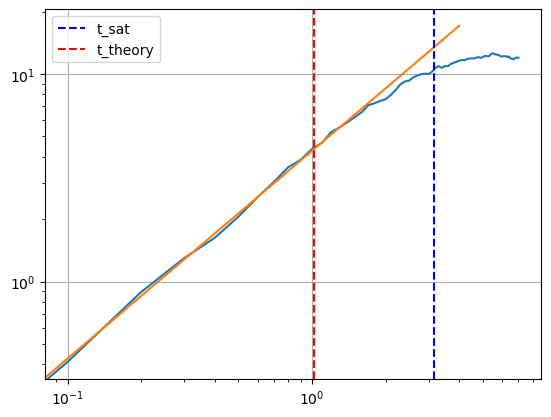

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output


t_sat = data['z_mean']['t_sat']
eta = climate['z_dot'].mean()
nu = config['atmosphere']['params']['nu']
p = config['atmosphere']['params']['p']
kf = config['atmosphere']['params']['kf']
k_diss = 1/(t_sat * nu)**(1/(2*p))
tau_nl = (eta)**(-1/3)
N_oct = np.log(k_diss/kf) / np.log(2)
t_sat_theory = tau_nl * N_oct
С_cas = t_sat/(tau_nl * N_oct)
print(t_sat, t_sat_theory, N_oct, С_cas)

e_mean, z_mean, t = climate['e_mean'], climate['z_mean'], climate['t']
# e, z = E.isel(t=-1), Z.isel(t=-1)
a, b = 1, 1.45
log_y = a * np.log(t[t<4]) + b 
plt.loglog(t, z_mean)
plt.loglog(t[t<4], np.exp(log_y))
plt.axvline(t_sat, color='b', linestyle='--', label='t_sat')
plt.axvline(t_sat_theory, color='r', linestyle='--', label='t_theory')
plt.legend()
plt.grid(True)
plt.show()
clear_output(wait=True)

In [73]:
import numpy as np
C_cas_0 = 1.37
data['z_mean']
t_sat = data['z_mean']['t_sat']
eta = climate['z_dot'].mean()
nu = config['atmosphere']['params']['nu']
p = config['atmosphere']['params']['p']
kf = config['atmosphere']['params']['kf']
tau_nl = (eta)**(-1/3)
k_diss = 1/(tau_nl * nu)**(1/(2*p))
N_oct = np.log(k_diss/kf) / np.log(2)
t_sat_theory = tau_nl * N_oct
С_cas = t_sat/(tau_nl * N_oct)
t_sat, t_sat_theory, N_oct, С_cas

(np.float64(4.239964293218197),
 <xarray.DataArray 'z_dot' ()> Size: 8B
 Array(2.15557673, dtype=float64),
 <xarray.DataArray 'z_dot' ()> Size: 8B
 array(2.14149174),
 <xarray.DataArray 'z_dot' ()> Size: 8B
 array(1.96697443))

/home/vchernosov/miniconda3/envs/climate/lib/python3.11/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


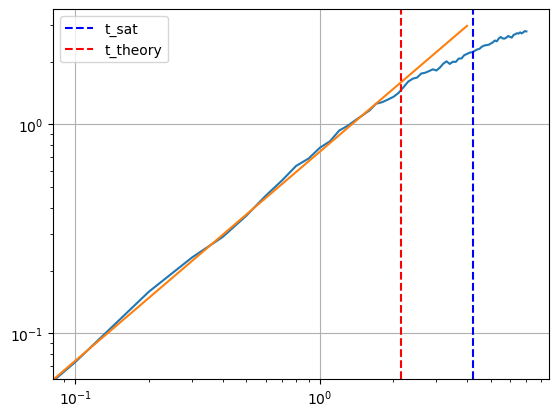

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output


t_sat = data['z_mean']['t_sat']
eta = climate['z_dot'].mean()
nu = config['atmosphere']['params']['nu']
p = config['atmosphere']['params']['p']
k_diss = 1/(t_sat * nu)**(1/(2*p))
tau_nl = (eta)**(-1/3)
N_oct = np.log(k_diss/kf) / np.log(2)
t_sat_theory = tau_nl * N_oct

e_mean, z_mean, t = climate['e_mean'], climate['z_mean'], climate['t']
# e, z = E.isel(t=-1), Z.isel(t=-1)
a, b = 1, -0.3
log_y = a * np.log(t[t<4]) + b 
plt.loglog(t, z_mean)
plt.loglog(t[t<4], np.exp(log_y))
plt.axvline(t_sat, color='b', linestyle='--', label='t_sat')
plt.axvline(t_sat_theory, color='r', linestyle='--', label='t_theory')
plt.legend()
plt.grid(True)
plt.show()
clear_output(wait=True)

In [37]:
import numpy as np
C_cas_0 = 1.37
data['z_mean']
t_sat = data['z_mean']['t_sat']
eta = climate['z_dot'].mean()
nu = config['atmosphere']['params']['nu']
p = config['atmosphere']['params']['p']
kf = config['atmosphere']['params']['kf']
tau_nl = (eta)**(-1/3)
k_diss = 1/(tau_nl * nu)**(1/(2*p))
N_oct = np.log(k_diss/kf) / np.log(2)
t_sat_theory = tau_nl * N_oct
С_cas = t_sat/(tau_nl * N_oct)
t_sat, t_sat_theory, N_oct, С_cas

(np.float64(1.7603000382257978),
 <xarray.DataArray 'z_dot' ()> Size: 8B
 Array(0.66778615, dtype=float64),
 <xarray.DataArray 'z_dot' ()> Size: 8B
 array(2.63956699),
 <xarray.DataArray 'z_dot' ()> Size: 8B
 array(2.63602359))

/home/vchernosov/miniconda3/envs/climate/lib/python3.11/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


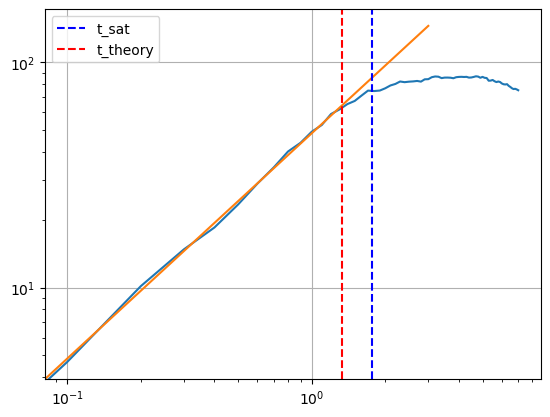

In [66]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

t_sat = data['z_mean']['t_sat']
eta = climate['z_dot'].mean()
nu = config['atmosphere']['params']['nu']
p = config['atmosphere']['params']['p']
k_diss = 1/(t_sat * nu)**(1/(2*p))
tau_nl = (eta)**(-1/3)
k_nl = 1/(tau_nl * nu)**(1/(2*p))

e_mean, z_mean, t = climate['e_mean'], climate['z_mean'], climate['t']
# e, z = E.isel(t=-1), Z.isel(t=-1)
a, b = 1, 3.88
log_y = a * np.log(t[t<3]) + b 
plt.loglog(t, z_mean)
plt.loglog(t[t<3], np.exp(log_y))
plt.axvline(t_sat, color='b', linestyle='--', label='t_sat')
plt.axvline(2*t_sat_theory, color='r', linestyle='--', label='t_theory')
plt.legend()
plt.grid(True)
plt.show()
clear_output(wait=True)

In [30]:
import numpy as np
C_cas_0 = 1.37
data['z_mean']
t_sat = data['z_mean']['t_sat']
eta = climate['z_dot'].mean()
nu = config['atmosphere']['params']['nu']
p = config['atmosphere']['params']['p']
kf = config['atmosphere']['params']['kf']
tau_nl = (eta)**(-1/3)
k_diss = 1/(tau_nl * nu)**(1/(2*p))
N_oct = np.log(k_diss/kf) / np.log(2)
t_sat_theory = tau_nl * N_oct
С_cas = t_sat/(tau_nl * N_oct)
t_sat, t_sat_theory, N_oct, С_cas

(np.float64(1.6051171148634689),
 <xarray.DataArray 'z_dot' ()> Size: 8B
 Array(0.51451103, dtype=float64),
 <xarray.DataArray 'z_dot' ()> Size: 8B
 array(2.05907416),
 <xarray.DataArray 'z_dot' ()> Size: 8B
 array(3.1196943))

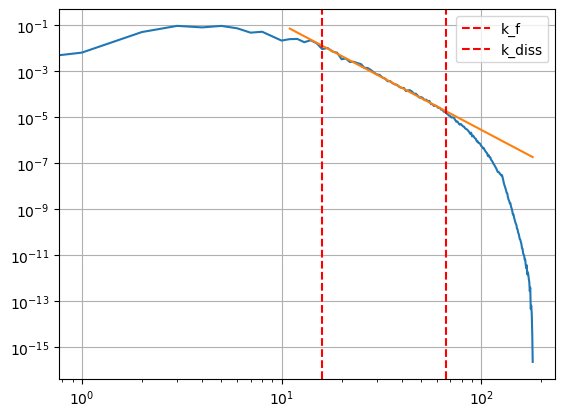

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

t_sat = data['z_mean']['t_sat']
eta = climate['z_dot'].mean()
nu = config['atmosphere']['params']['nu']
p = config['atmosphere']['params']['p']
k_diss = 1/(t_sat * nu)**(1/(2*p))
tau_nl = (eta)**(-1/3)
k_nl = 1/(tau_nl * nu)**(1/(2*p))

E, Z, k1 = climate['e'], climate['z'], climate['k1']
e, z = E.isel(t=-1), Z.isel(t=-1)
a, b = -4.6, 8.4
log_y = a * np.log(k1[k1>10]) + b 
plt.loglog(k1, e)
plt.loglog(k1[k1>10], np.exp(log_y))
plt.axvline(kf, color='r', linestyle='--', label='k_f')
plt.axvline(k_nl, color='r', linestyle='--', label='k_diss')
plt.legend()
plt.grid(True)
plt.show()
clear_output(wait=True)

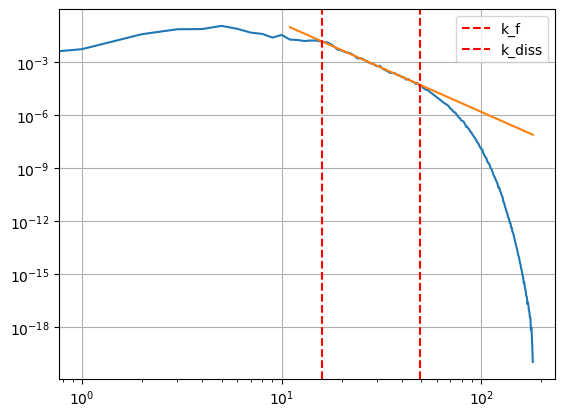

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

t_sat = data['z_mean']['t_sat']
eta = climate['z_dot'].mean()
nu = config['atmosphere']['params']['nu']
p = config['atmosphere']['params']['p']
k_diss = 1/(t_sat * nu)**(1/(2*p))
tau_nl = (eta)**(-1/3)
k_nl = 1/(tau_nl * nu)**(1/(2*p))

E, Z, k1 = climate['e'], climate['z'], climate['k1']
e, z = E.isel(t=-1), Z.isel(t=-1)
a, b = -5, 9.6
log_y = a * np.log(k1[k1>10]) + b 
plt.loglog(k1, e)
plt.loglog(k1[k1>10], np.exp(log_y))
plt.axvline(kf, color='r', linestyle='--', label='k_f')
plt.axvline(k_nl, color='r', linestyle='--', label='k_diss')
plt.legend()
plt.grid(True)
plt.show()
clear_output(wait=True)

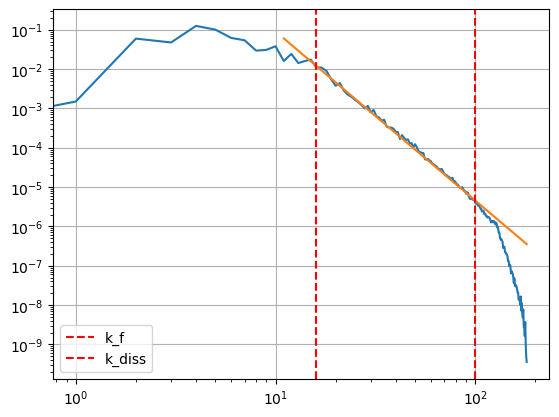

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

t_sat = data['z_mean']['t_sat']
eta = climate['z_dot'].mean()
nu = config['atmosphere']['params']['nu']
p = config['atmosphere']['params']['p']
k_diss = 1/(t_sat * nu)**(1/(2*p))
tau_nl = (eta)**(-1/3)
k_nl = 1/(tau_nl * nu)**(1/(2*p))

E, Z, k1 = climate['e'], climate['z'], climate['k1']
e, z = E.isel(t=-1), Z.isel(t=-1)
a, b = -4.3, 7.5
log_y = a * np.log(k1[k1>10]) + b 
plt.loglog(k1, e)
plt.loglog(k1[k1>10], np.exp(log_y))
plt.axvline(kf, color='r', linestyle='--', label='k_f')
plt.axvline(k_nl, color='r', linestyle='--', label='k_diss')
plt.legend()
plt.grid(True)
plt.show()
clear_output(wait=True)

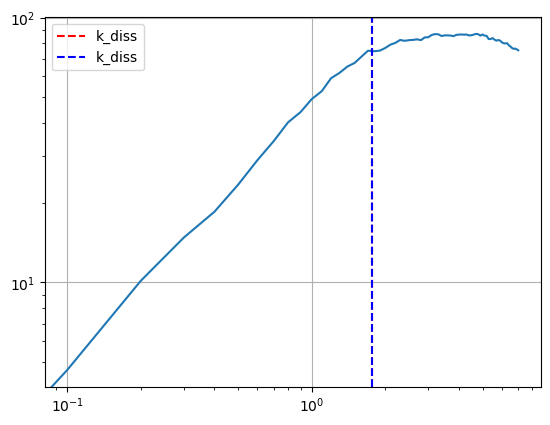

<xarray.DataArray 'z_dot' ()> Size: 8B
Array(1.77093555, dtype=float64) 1.7603000382257978


In [88]:
e_mean, z_mean, t = climate['e_mean'], climate['z_mean'], climate['t']
plt.loglog(t, z_mean)
plt.axvline(data['z_mean']['t_sat'], color='r', linestyle='--', label='k_diss')
plt.axvline(tau_nl*7, color='b', linestyle='--', label='k_diss')
plt.legend()
plt.grid(True)
plt.show()
print(tau_nl*7, data['z_mean']['t_sat'])